# Computational Gastronomy — Assignment 1 — Question 2

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("data")
OUT_DIR = Path("q2_output")
OUT_DIR.mkdir(exist_ok=True)

BLUE = "#2a78d6"  # single-series accent used throughout

# (Recipe ID, Ingredient Name) table produced in Q1(c)
pairs = pd.read_csv(DATA_DIR / "recipe_id_ingredient_name.csv")
print("Loaded", len(pairs), "(recipe_id, ingredient_name) rows covering",
      pairs["recipe_id"].nunique(), "recipes")
pairs.head()

Loaded 98309 (recipe_id, ingredient_name) rows covering 10000 recipes


,recipe_id,ingredient_name
0,1,seedless orange
1,1,lemon
2,1,olive oil
3,1,almonds
4,1,polenta


## Q2(a) — Number of unique ingredients and their frequencies

In [2]:
ingredient_freq = (
    pairs["ingredient_name"]
    .value_counts()
    .rename_axis("ingredient_name")
    .reset_index(name="frequency")
)

n_unique = len(ingredient_freq)
print(f"Number of unique ingredients: {n_unique}")

freq_path = OUT_DIR / "q2a_unique_ingredient_frequencies.csv"
ingredient_freq.to_csv(freq_path, index=False)
print(f"Saved -> {freq_path}")

ingredient_freq.head(15)

Number of unique ingredients: 13825
Saved -> q2_output/q2a_unique_ingredient_frequencies.csv


,ingredient_name,frequency
0,olive oil,2732
1,butter,2045
2,flour,1669
3,eggs,1494
4,garlic,1201
5,onion,1170
6,caster sugar,1104
7,milk,1029
8,golden caster sugar,997
9,garlic clove,917


## Q2(b) — Recipe size distribution

In [3]:
# Recipe size = number of (extracted) ingredients in that recipe
recipe_sizes = pairs.groupby("recipe_id").size()

s = recipe_sizes.mean()
print(f"Number of recipes: {len(recipe_sizes)}")
print(f"Average recipe size (s): {s:.2f} ingredients")
print(recipe_sizes.describe())

Number of recipes: 10000
Average recipe size (s): 9.83 ingredients
count    10000.000000
mean         9.830900
std          4.294665
min          1.000000
25%          7.000000
50%          9.000000
75%         12.000000
max         59.000000
dtype: float64


Saved -> q2_output/q2b_recipe_size_distribution.png


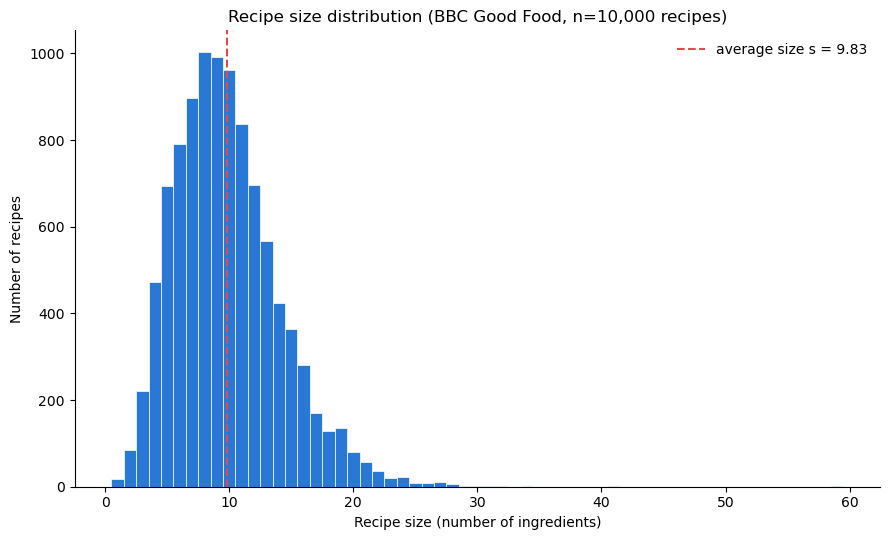

In [4]:
fig, ax = plt.subplots(figsize=(9, 5.5))

bins = np.arange(recipe_sizes.min(), recipe_sizes.max() + 2) - 0.5
ax.hist(recipe_sizes, bins=bins, color=BLUE, edgecolor="white", linewidth=0.5)

ax.axvline(s, color="#e34948", linestyle="--", linewidth=1.5,
            label=f"average size s = {s:.2f}")

ax.set_title("Recipe size distribution (BBC Good Food, n=10,000 recipes)")
ax.set_xlabel("Recipe size (number of ingredients)")
ax.set_ylabel("Number of recipes")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()

out_path = OUT_DIR / "q2b_recipe_size_distribution.png"
fig.savefig(out_path, dpi=150)
print(f"Saved -> {out_path}")
plt.show()

## Q2(c) — Cumulative distribution of recipe size

Saved -> q2_output/q2c_recipe_size_cumulative_distribution.png


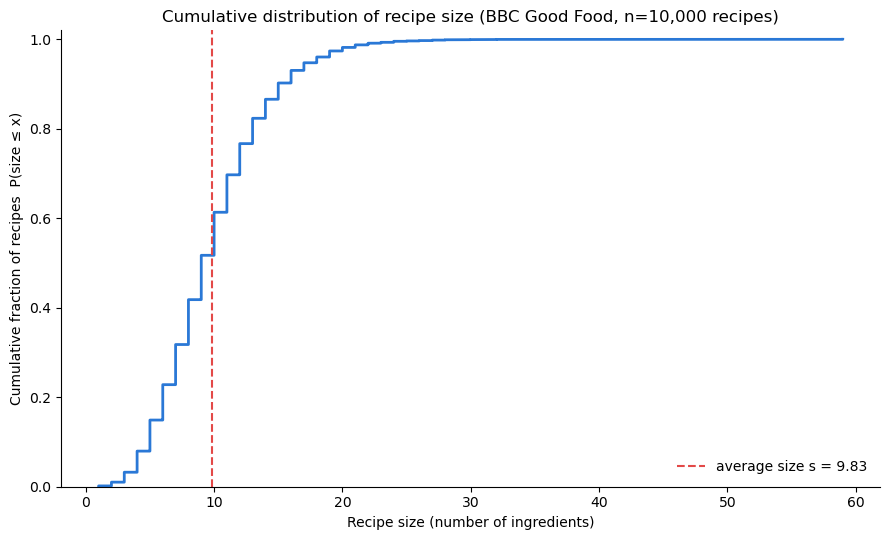

In [5]:
sorted_sizes = np.sort(recipe_sizes.values)
cumulative_fraction = np.arange(1, len(sorted_sizes) + 1) / len(sorted_sizes)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.step(sorted_sizes, cumulative_fraction, where="post", color=BLUE, linewidth=2)

ax.axvline(s, color="#e34948", linestyle="--", linewidth=1.5,
            label=f"average size s = {s:.2f}")

ax.set_title("Cumulative distribution of recipe size (BBC Good Food, n=10,000 recipes)")
ax.set_xlabel("Recipe size (number of ingredients)")
ax.set_ylabel("Cumulative fraction of recipes  P(size \u2264 x)")
ax.set_ylim(0, 1.02)
ax.legend(frameon=False, loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()

out_path = OUT_DIR / "q2c_recipe_size_cumulative_distribution.png"
fig.savefig(out_path, dpi=150)
print(f"Saved -> {out_path}")
plt.show()

## Files produced

- `q2_output/q2a_unique_ingredient_frequencies.csv`
- `q2_output/q2b_recipe_size_distribution.png`
- `q2_output/q2c_recipe_size_cumulative_distribution.png`